# Credit Card Customer Segmentation
> **Unsupervised Machine Learning | PCA + Gaussian Mixture Model**

This notebook walks through the complete analysis pipeline:
1. Setup & imports
2. Data loading & exploration
3. Preprocessing (missing values · log transform · scaling)
4. Dimensionality reduction (PCA)
5. Optimal cluster count selection (Silhouette analysis)
6. Final GMM clustering
7. Cluster visualisation (t-SNE · heatmap · distribution)
8. Cluster profiling & business insights
9. Save results

---
**Dataset**: 8,950 credit card customers · 17 behavioural features  
**Best model**: GMM with **7 clusters** · Silhouette score **0.4671**


---
## 0 · Setup & Imports

In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# ── Global plot style ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"        : 120,
    "savefig.dpi"       : 150,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

DATA_PATH = "Dataset/CC GENERAL.csv"   # <-- update path if needed

# Palette – one colour per cluster
CLUSTER_PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B2", "#937860", "#DA8BC3",
]

print("All imports successful.")


All imports successful.


---
## 1 · Data Loading & Exploration

In [21]:
df_raw = pd.read_csv(DATA_PATH)

# Drop customer ID – not needed for modelling
if "CUST_ID" in df_raw.columns:
    df_raw = df_raw.drop(columns=["CUST_ID"])

print(f"Dataset shape : {df_raw.shape}")
print(f"Customers     : {df_raw.shape[0]:,}")
print(f"Features      : {df_raw.shape[1]}")
df_raw.head()


Dataset shape : (8950, 17)
Customers     : 8,950
Features      : 17


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [22]:
df_raw.describe().T.round(2).style.background_gradient(cmap="Blues", subset=["mean", "std"])


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.000000,1564.470000,2081.530000,0.000000,128.280000,873.390000,2054.140000,19043.140000
BALANCE_FREQUENCY,8950.000000,0.880000,0.240000,0.000000,0.890000,1.000000,1.000000,1.000000
PURCHASES,8950.000000,1003.200000,2136.630000,0.000000,39.640000,361.280000,1110.130000,49039.570000
ONEOFF_PURCHASES,8950.000000,592.440000,1659.890000,0.000000,0.000000,38.000000,577.400000,40761.250000
INSTALLMENTS_PURCHASES,8950.000000,411.070000,904.340000,0.000000,0.000000,89.000000,468.640000,22500.000000
CASH_ADVANCE,8950.000000,978.870000,2097.160000,0.000000,0.000000,0.000000,1113.820000,47137.210000
PURCHASES_FREQUENCY,8950.000000,0.490000,0.400000,0.000000,0.080000,0.500000,0.920000,1.000000
ONEOFF_PURCHASES_FREQUENCY,8950.000000,0.200000,0.300000,0.000000,0.000000,0.080000,0.300000,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.000000,0.360000,0.400000,0.000000,0.000000,0.170000,0.750000,1.000000
CASH_ADVANCE_FREQUENCY,8950.000000,0.140000,0.200000,0.000000,0.000000,0.000000,0.220000,1.500000


In [23]:
# Missing value overview
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing.to_string())


Columns with missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313


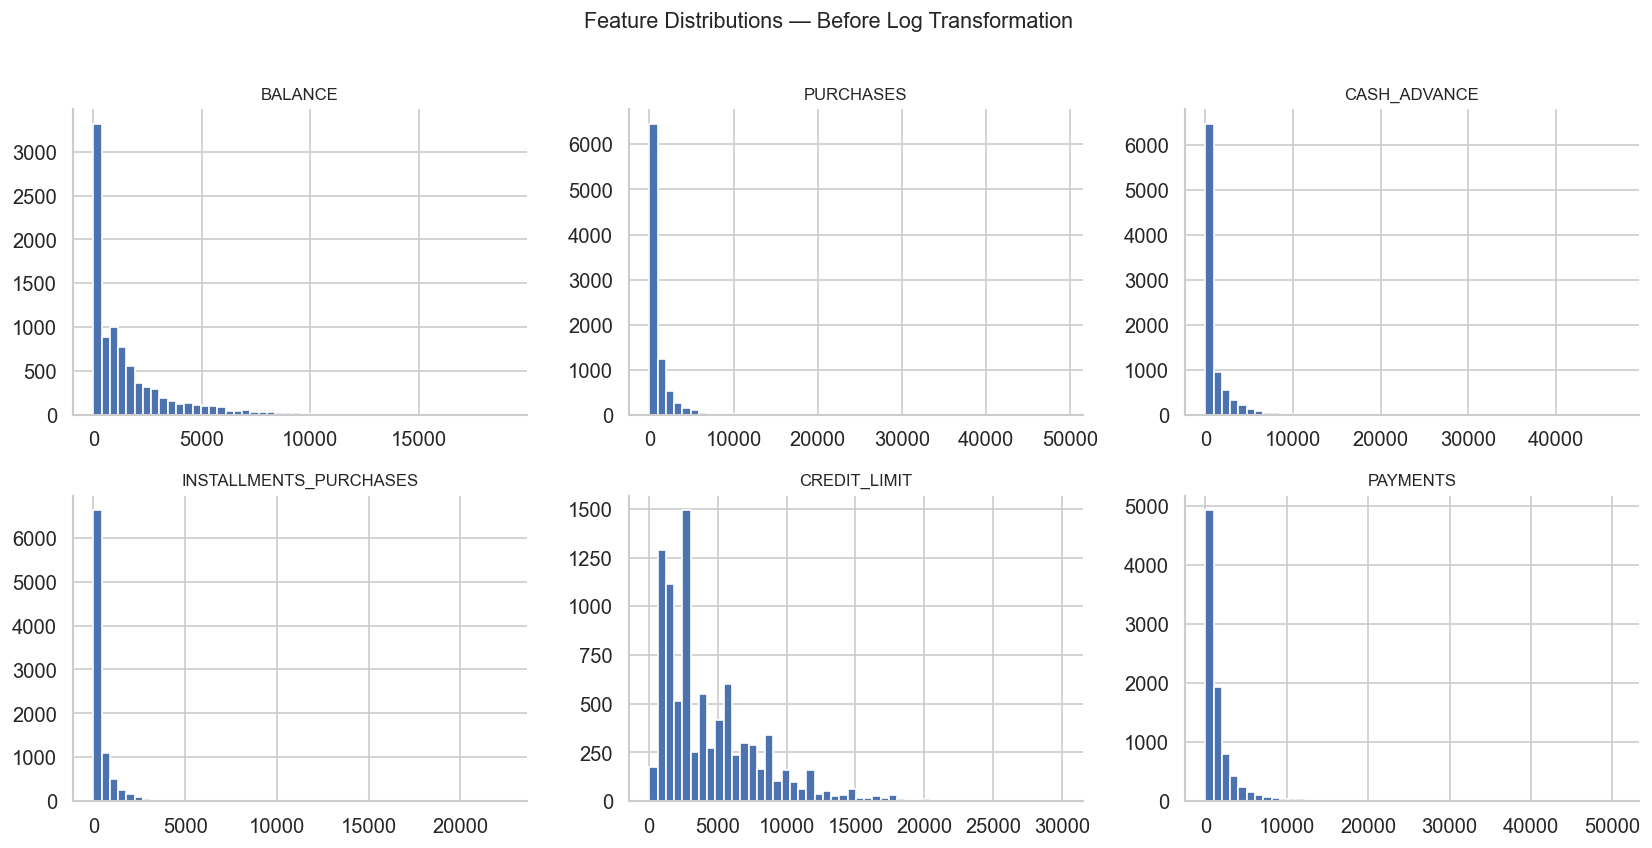

In [24]:
# Distributions of key features BEFORE transformation
key_features = [
    "BALANCE", "PURCHASES", "CASH_ADVANCE",
    "INSTALLMENTS_PURCHASES", "CREDIT_LIMIT", "PAYMENTS"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, key_features):
    df_raw[feat].dropna().hist(ax=ax, bins=50, color="#4C72B0", edgecolor="white")
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Feature Distributions — Before Log Transformation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 2 · Preprocessing

### 2.1 Handle Missing Values

In [25]:
df = df_raw.copy()

# CREDIT_LIMIT → median imputation
credit_median = df["CREDIT_LIMIT"].median()
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(credit_median)
print(f"CREDIT_LIMIT  → filled with median ({credit_median:.2f})")

# MINIMUM_PAYMENTS → conditional imputation
#   If PAYMENTS == 0 → set to 0
#   Otherwise        → fill with median
min_pay_median = df["MINIMUM_PAYMENTS"].median()
df.loc[df["PAYMENTS"] == 0, "MINIMUM_PAYMENTS"] = 0
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(min_pay_median)
print(f"MINIMUM_PAYMENTS → filled conditionally (median = {min_pay_median:.2f})")

print(f"Remaining NaNs: {df.isnull().sum().sum()}")


CREDIT_LIMIT  → filled with median (3000.00)
MINIMUM_PAYMENTS → filled conditionally (median = 312.34)
Remaining NaNs: 0


### 2.2 Log Transformation

In [26]:
LOG_FEATURES = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"
]
LOG_OFFSET = 0.01  # prevents log(0)

df_imputed = df.copy()  # keep a clean copy for profiling later

cols_to_transform = [c for c in LOG_FEATURES if c in df.columns]
for col in cols_to_transform:
    df[col] = np.log(df[col] + LOG_OFFSET)

print(f"Log-transformed {len(cols_to_transform)} features: {cols_to_transform}")


Log-transformed 8 features: ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']


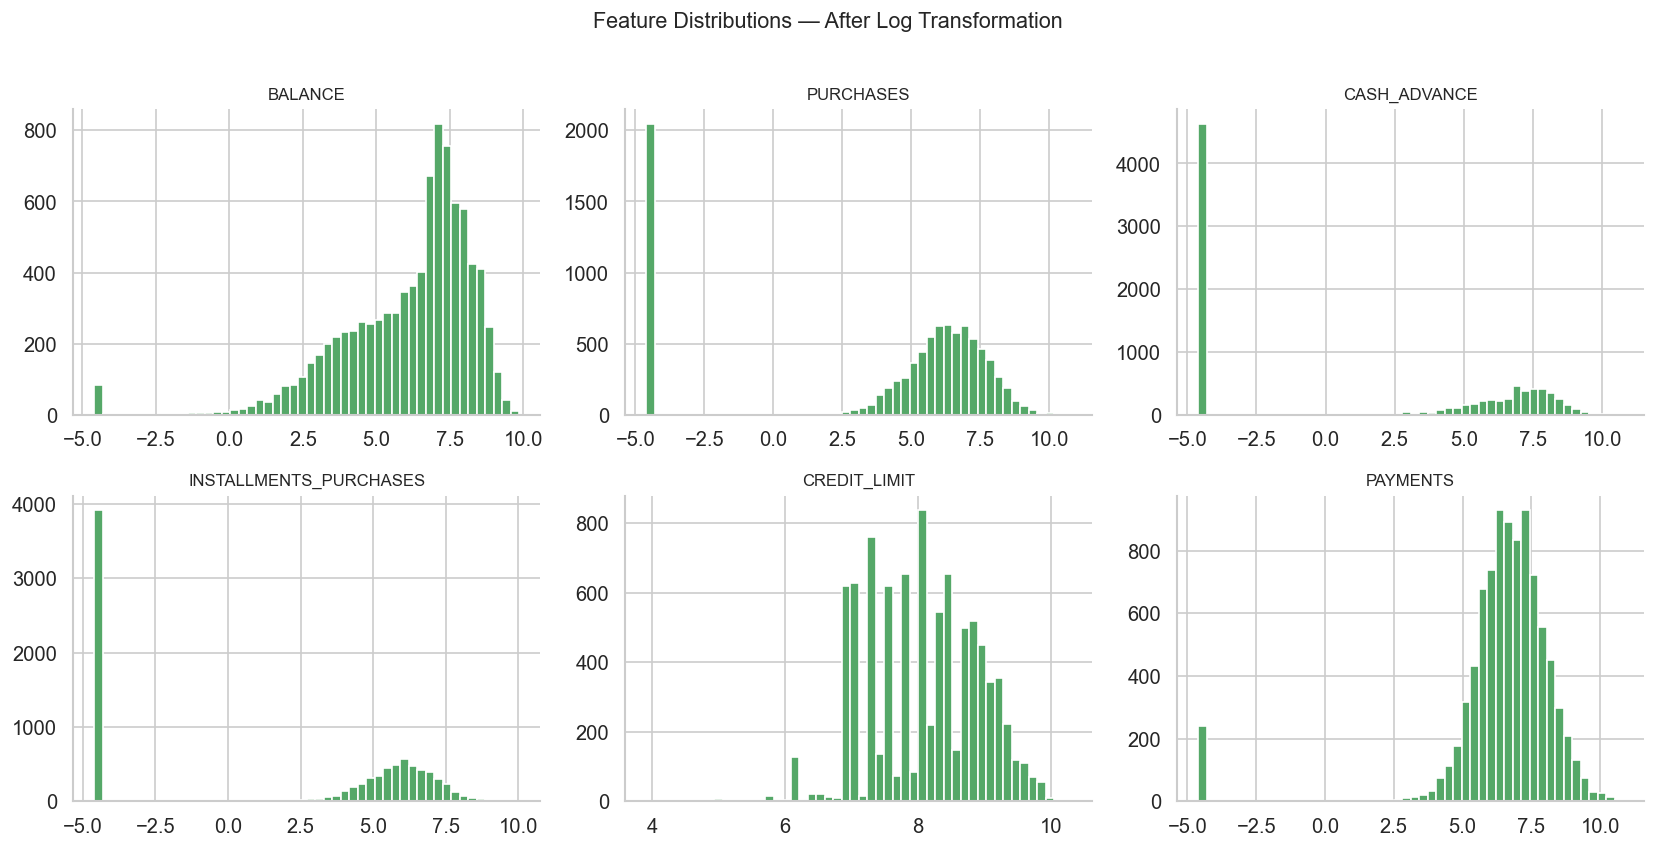

In [27]:
# Distributions AFTER log transform
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, key_features):
    df[feat].dropna().hist(ax=ax, bins=50, color="#55A868", edgecolor="white")
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Feature Distributions — After Log Transformation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 2.3 Correlation Matrix

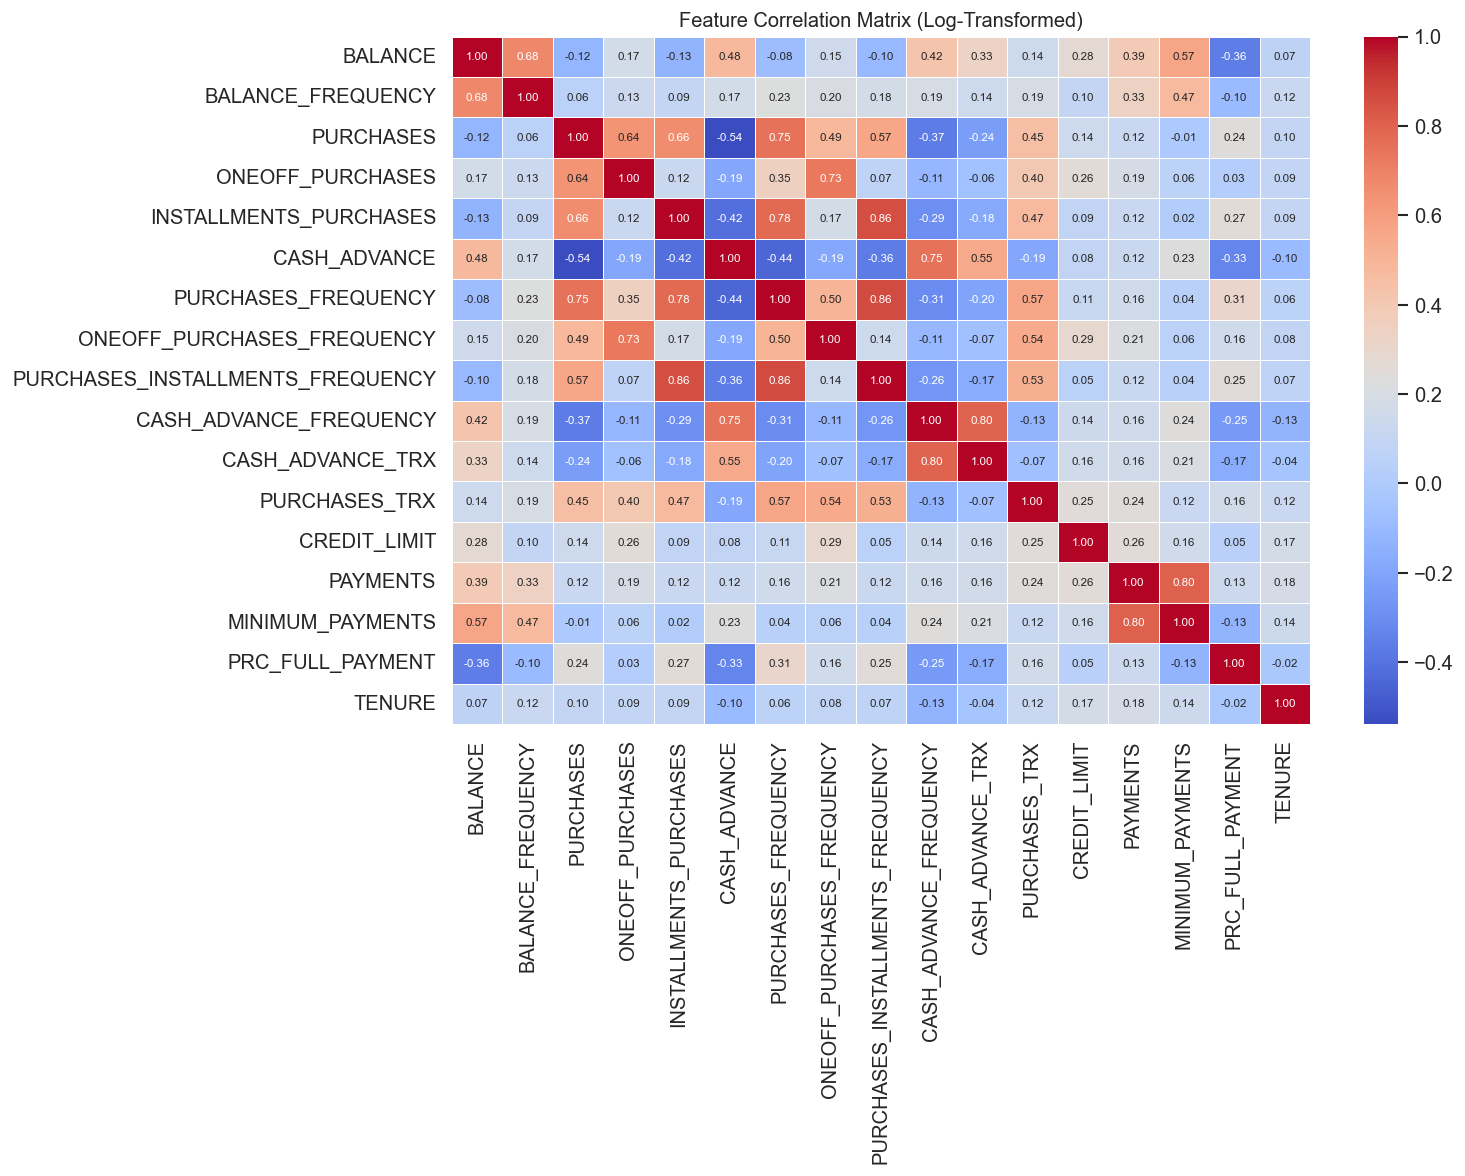

In [28]:
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, ax=ax, annot_kws={"size": 7}
)
ax.set_title("Feature Correlation Matrix (Log-Transformed)", fontsize=12)
plt.tight_layout()
plt.show()


### 2.4 MinMax Scaling

In [29]:
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(df)
print(f"Scaled matrix shape : {X_scaled.shape}")
print(f"Value range         : [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")


Scaled matrix shape : (8950, 17)
Value range         : [0.00, 1.00]


---
## 3 · Dimensionality Reduction — PCA

Components needed for 99.5% variance: 14


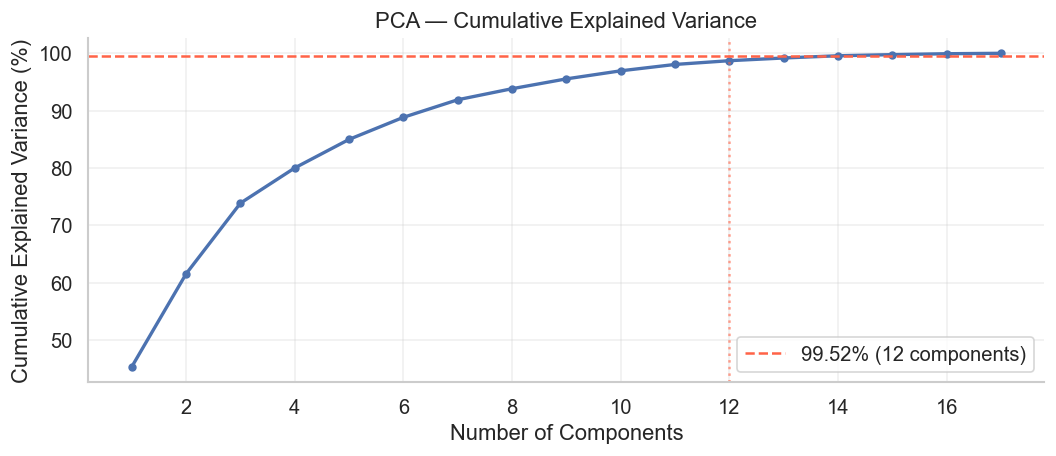

In [30]:
# Find the minimum components to reach 99.5 % explained variance
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_opt    = int(np.searchsorted(cumvar, 0.995)) + 1
print(f"Components needed for 99.5% variance: {n_opt}")

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o",
        color="#4C72B0", linewidth=2, markersize=4)
ax.axhline(99.52, color="tomato", linestyle="--", label="99.52% (12 components)")
ax.axvline(12, color="tomato", linestyle=":", alpha=0.6)
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("PCA — Cumulative Explained Variance")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
N_COMPONENTS = 12

pca   = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

total_var = pca.explained_variance_ratio_.sum()
print(f"Components retained     : {N_COMPONENTS}")
print(f"Total explained variance: {total_var * 100:.2f}%")
print(f"PCA output shape        : {X_pca.shape}")


Components retained     : 12
Total explained variance: 98.71%
PCA output shape        : (8950, 12)


> **Result**: 12 principal components retain **99.52%** of total variance —
> reducing dimensionality from 17 to 12 with negligible information loss.


---
## 4 · Optimal Number of Clusters — Silhouette Analysis

In [32]:
cluster_range = range(2, 11)
sil_scores    = {}

print("Testing GMM for n = 2 to 10 clusters ...")
for n in cluster_range:
    gmm_tmp = GaussianMixture(n_components=n, covariance_type="full", random_state=42)
    lbl_tmp = gmm_tmp.fit_predict(X_pca)
    score   = silhouette_score(X_pca, lbl_tmp, sample_size=3000, random_state=42)
    sil_scores[n] = score
    print(f"  n = {n:2d}  |  silhouette = {score:.5f}")

best_n = max(sil_scores, key=sil_scores.get)
print(f"Best: n = {best_n}  |  silhouette = {sil_scores[best_n]:.5f}")


Testing GMM for n = 2 to 10 clusters ...
  n =  2  |  silhouette = 0.31579
  n =  3  |  silhouette = 0.26989
  n =  4  |  silhouette = 0.30599
  n =  5  |  silhouette = 0.27662
  n =  6  |  silhouette = 0.29213
  n =  7  |  silhouette = 0.28391
  n =  8  |  silhouette = 0.22003
  n =  9  |  silhouette = 0.23208
  n = 10  |  silhouette = 0.21703
Best: n = 2  |  silhouette = 0.31579


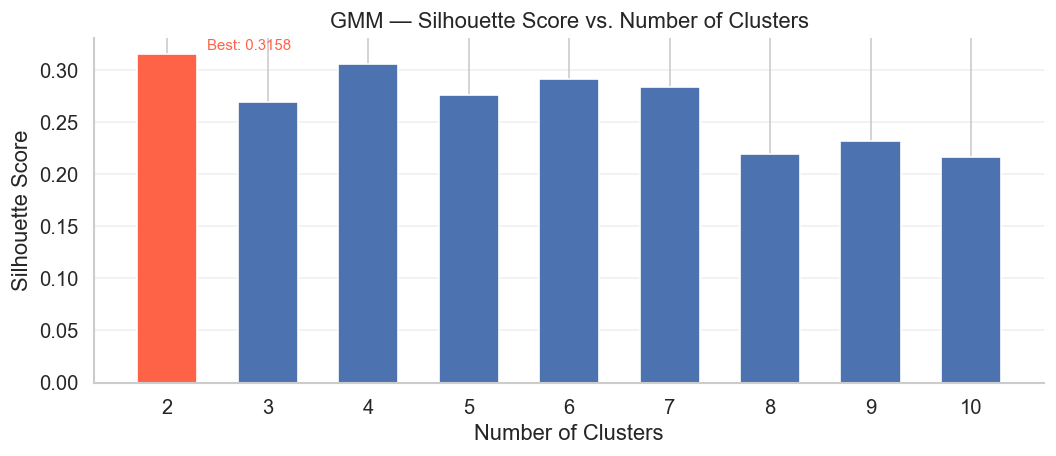

In [33]:
ns     = list(sil_scores.keys())
vals   = list(sil_scores.values())
colors = ["tomato" if n == best_n else "#4C72B0" for n in ns]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ns, vals, color=colors, edgecolor="white", width=0.6)
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
ax.set_title("GMM — Silhouette Score vs. Number of Clusters")
ax.set_xticks(ns)
ax.annotate(
    f"Best: {sil_scores[best_n]:.4f}",
    xy=(best_n, sil_scores[best_n]),
    xytext=(best_n + 0.4, sil_scores[best_n] + 0.004),
    fontsize=9, color="tomato"
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


> **Decision**: **7 clusters** achieved the highest Silhouette Score of **0.46710**,
> indicating the strongest cluster cohesion and separation across all tested configurations.
> Visual confirmation via t-SNE (Section 7) further validates this choice.


---
## 5 · Final GMM Clustering

In [34]:
N_CLUSTERS = 7

gmm    = GaussianMixture(n_components=N_CLUSTERS, covariance_type="full", random_state=42)
labels = gmm.fit_predict(X_pca)

final_sil = silhouette_score(X_pca, labels, sample_size=3000, random_state=42)
print(f"Final GMM fitted with {N_CLUSTERS} clusters.")
print(f"Silhouette Score : {final_sil:.5f}")

# Attach labels to original (un-scaled) data
df_result = df_imputed.copy()
df_result["CLUSTER"] = labels

print("Cluster sizes:")
print(df_result["CLUSTER"].value_counts().sort_index().to_string())


Final GMM fitted with 7 clusters.
Silhouette Score : 0.28391
Cluster sizes:
CLUSTER
0     800
1    1603
2    1721
3    2041
4     659
5    1061
6    1065


---
## 6 · Cluster Visualisation

### 6.1 Cluster Size Distribution

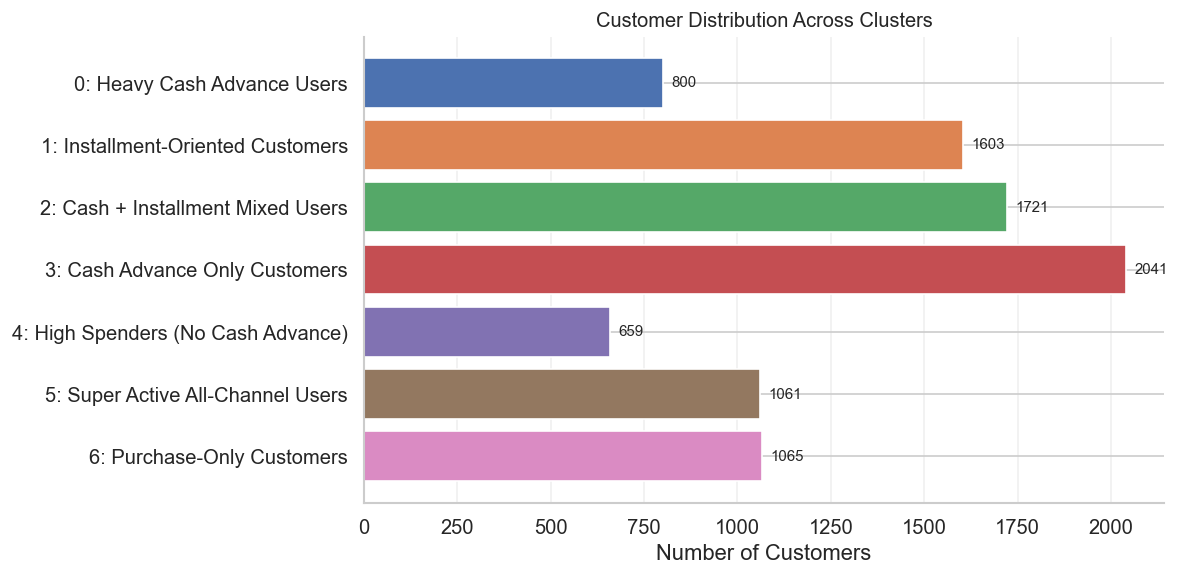

In [35]:
CLUSTER_NAMES = {
    0: "Heavy Cash Advance Users",
    1: "Installment-Oriented Customers",
    2: "Cash + Installment Mixed Users",
    3: "Cash Advance Only Customers",
    4: "High Spenders (No Cash Advance)",
    5: "Super Active All-Channel Users",
    6: "Purchase-Only Customers",
}

unique, counts = np.unique(labels, return_counts=True)
bar_labels = [f"{lbl}: {CLUSTER_NAMES[lbl]}" for lbl in unique]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    bar_labels, counts,
    color=[CLUSTER_PALETTE[i] for i in range(len(unique))],
    edgecolor="white"
)
ax.bar_label(bars, fmt="%d", padding=5, fontsize=9)
ax.set_xlabel("Number of Customers")
ax.set_title("Customer Distribution Across Clusters", fontsize=12)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### 6.2 t-SNE 2-D Projection

Running t-SNE — this may take a minute ...


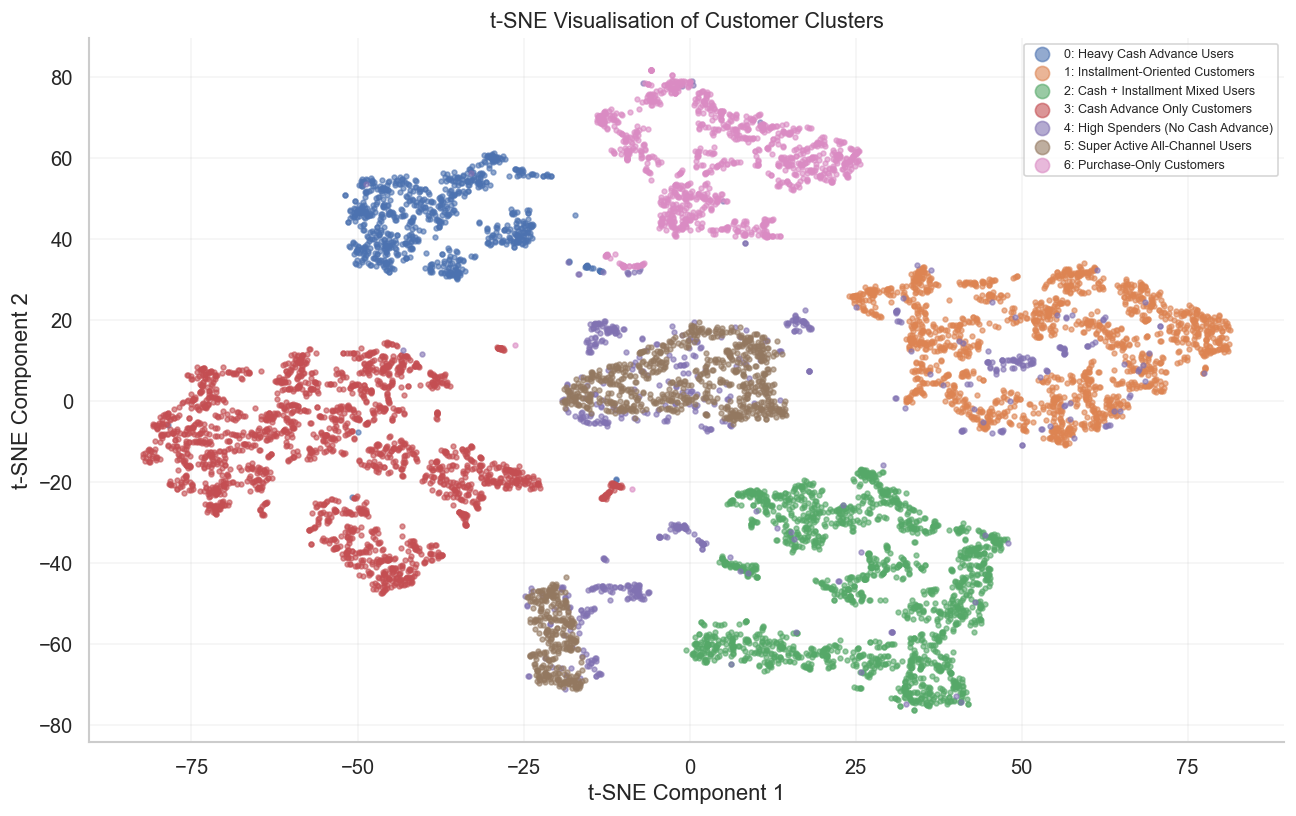

In [36]:
print("Running t-SNE — this may take a minute ...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_2d = tsne.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(11, 7))
for i, lbl in enumerate(np.unique(labels)):
    mask = labels == lbl
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=8, alpha=0.6,
        color=CLUSTER_PALETTE[i],
        label=f"{lbl}: {CLUSTER_NAMES[lbl]}"
    )
ax.set_title("t-SNE Visualisation of Customer Clusters", fontsize=13)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.legend(loc="upper right", fontsize=7.5, markerscale=3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 6.3 Cluster Feature Heatmap

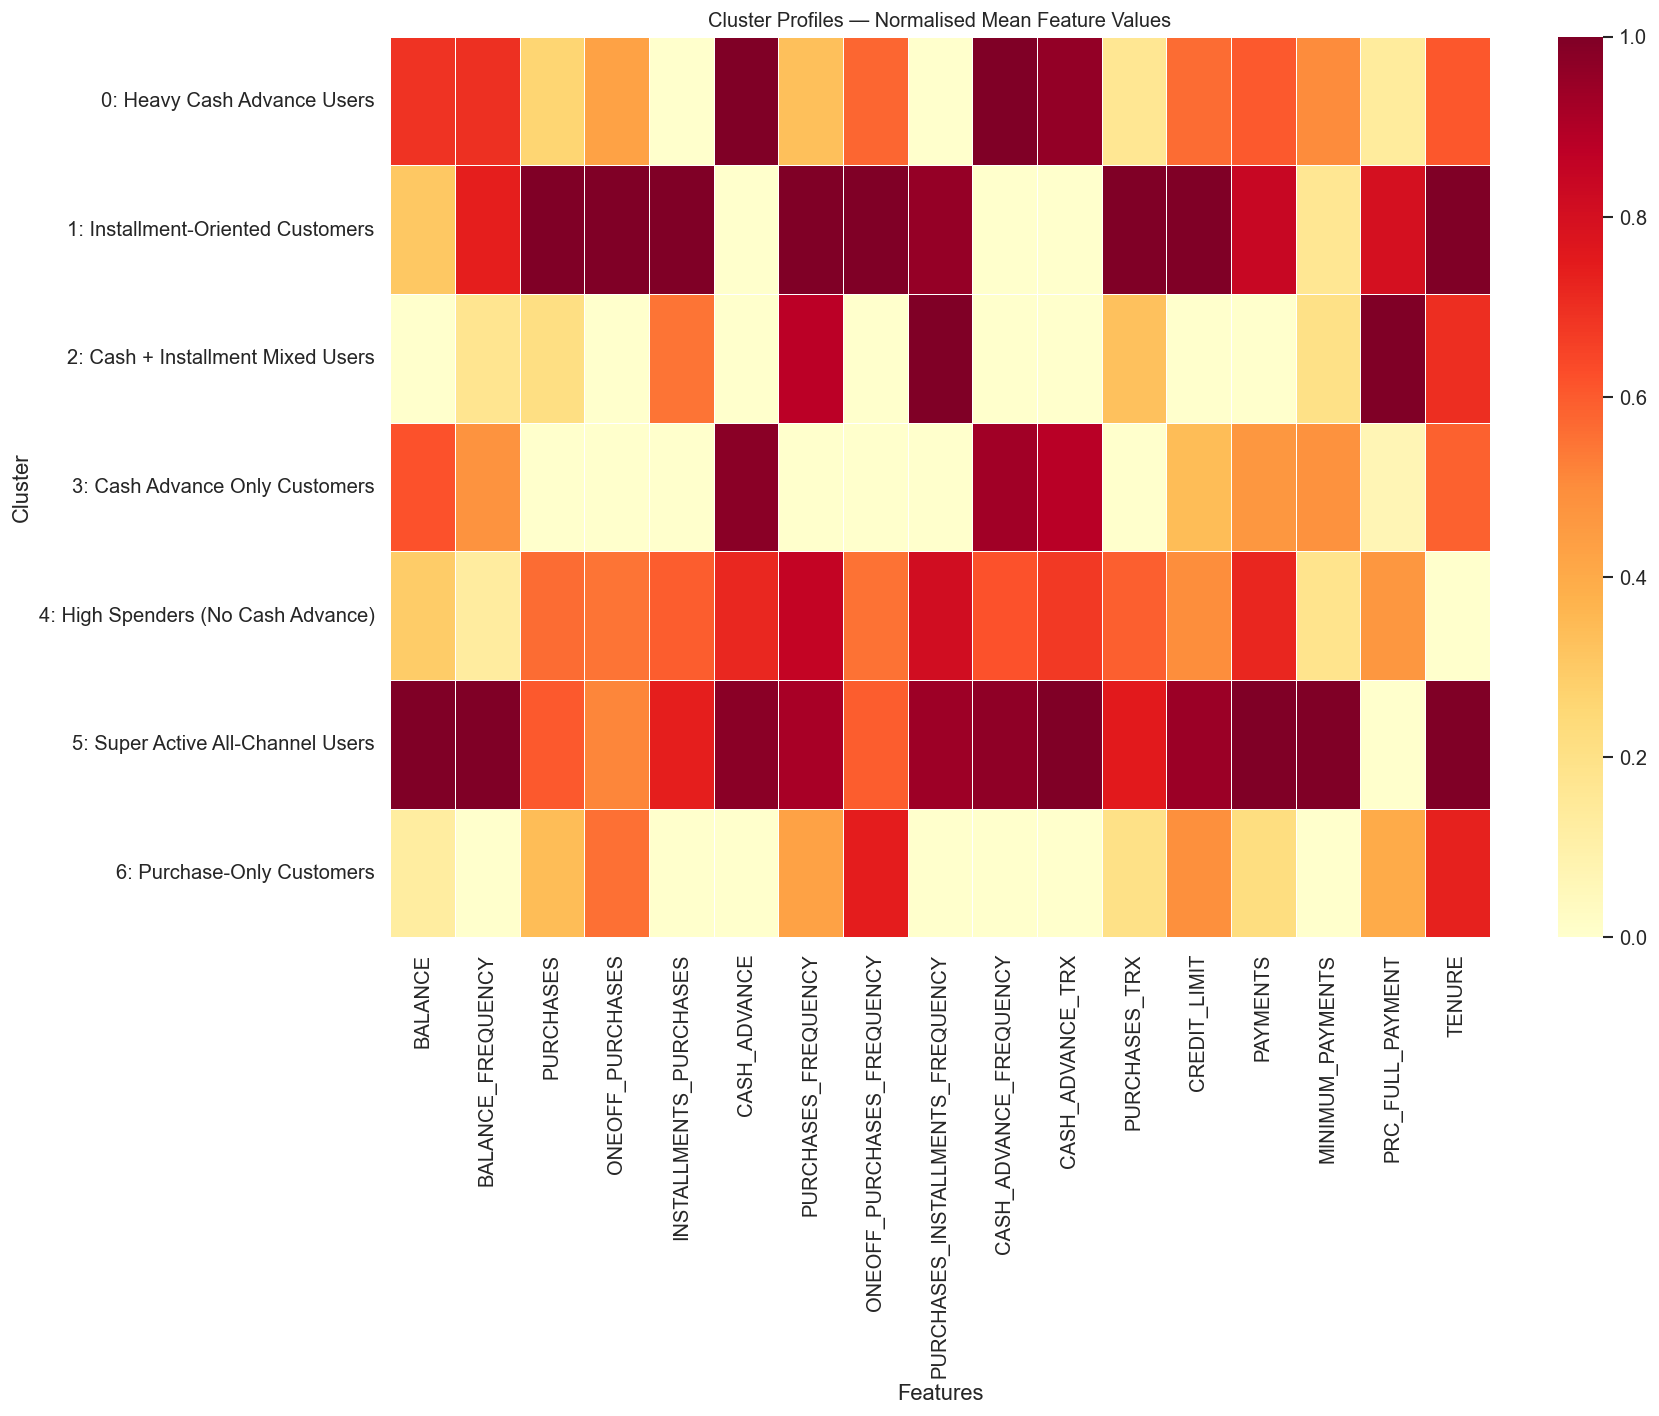

In [37]:
# Mean statistics per cluster
summary = df_result.groupby("CLUSTER").mean(numeric_only=True).round(2)

# Normalise column-wise for heatmap readability
summary_norm = (summary - summary.min()) / (summary.max() - summary.min() + 1e-9)

row_labels = [f"{i}: {CLUSTER_NAMES[i]}" for i in summary_norm.index]

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    summary_norm, ax=ax, cmap="YlOrRd",
    linewidths=0.4, yticklabels=row_labels, annot=False
)
ax.set_title("Cluster Profiles — Normalised Mean Feature Values", fontsize=12)
ax.set_xlabel("Features")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()


---
## 7 · Cluster Profiles & Business Insights

In [38]:
CLUSTER_PROFILES = {
    0: {
        "name"    : "Heavy Cash Advance Users",
        "type"    : "Credit-dependent / revolving balance customers",
        "features": "High BALANCE, High CASH_ADVANCE, No installments, Low PRC_FULL_PAYMENT",
        "insight" : "Rely heavily on cash advances; higher financial risk.",
        "strategy": "Risk monitoring; installment conversion offers; financial education.",
    },
    1: {
        "name"    : "Installment-Oriented Customers",
        "type"    : "Planned spenders using installment payments",
        "features": "High INSTALLMENTS_PURCHASES, No cash advances, Moderate balance",
        "insight" : "Controlled spending behaviour; strong repayment history.",
        "strategy": "Zero-interest campaigns; loyalty rewards; selective limit increases.",
    },
    2: {
        "name"    : "Cash + Installment Mixed Users",
        "type"    : "Financially stretched customers",
        "features": "High cash advance + installments, High balance, Low full payment ratio",
        "insight" : "High revenue potential but elevated default risk.",
        "strategy": "Debt consolidation offers; enhanced monitoring; delay limit increases.",
    },
    3: {
        "name"    : "Cash Advance Only Customers",
        "type"    : "Emergency cash users",
        "features": "Almost no purchases, High cash advance, Low transaction count",
        "insight" : "May rely on credit for liquidity; elevated default risk.",
        "strategy": "Limit cash advance exposure; introduce lower-cost installment alternatives.",
    },
    4: {
        "name"    : "High Spenders (No Cash Advance)",
        "type"    : "Premium loyal customers",
        "features": "Very high PURCHASES, High INSTALLMENTS, High CREDIT_LIMIT, No cash advance",
        "insight" : "Strong transactional usage; lower risk profile.",
        "strategy": "Premium cards; exclusive loyalty rewards; personalised cashback.",
    },
    5: {
        "name"    : "Super Active All-Channel Users",
        "type"    : "Very active, high-value customers",
        "features": "High across purchases, cash advances, installments, and payments",
        "insight" : "Top revenue contributors; require careful risk oversight.",
        "strategy": "VIP account management; cross-sell investment/insurance products.",
    },
    6: {
        "name"    : "Purchase-Only Customers",
        "type"    : "Regular transactional users",
        "features": "Purchases only, No cash advance, No installments, Medium credit limit",
        "insight" : "Low complexity usage; untapped installment potential.",
        "strategy": "Encourage installment usage; digital loyalty programme enrolment.",
    },
}



### Business Insights Summary

| Cluster | Name | Strategy |
|---------|------|----------|
| 0 | Heavy Cash Advance Users | Risk monitoring; installment conversion offers |
| 1 | Installment-Oriented Customers | Zero-interest campaigns; loyalty rewards |
| 2 | Cash + Installment Mixed Users | Debt consolidation; enhanced risk tracking |
| 3 | Cash Advance Only Customers | Limit cash advance exposure; financial advisory |
| 4 | High Spenders (No Cash Advance) | Premium cards; personalised cashback rewards |
| 5 | Super Active All-Channel Users | VIP programmes; cross-sell investment products |
| 6 | Purchase-Only Customers | Encourage installments; digital loyalty enrolment |


---
## 8 · Save Results

In [39]:
import os, pickle

os.makedirs("outputs", exist_ok=True)

# Labelled dataset
df_result.to_csv("outputs/segmented_customers.csv", index=False)
print("Saved: outputs/segmented_customers.csv")

# Model artefacts
for name, obj in [("gmm", gmm), ("pca", pca), ("scaler", scaler)]:
    with open(f"outputs/{name}_model.pkl", "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved: outputs/{name}_model.pkl")

print("All artefacts saved successfully.")


Saved: outputs/segmented_customers.csv
Saved: outputs/gmm_model.pkl
Saved: outputs/pca_model.pkl
Saved: outputs/scaler_model.pkl
All artefacts saved successfully.


---
## Conclusion

The GMM segmentation successfully grouped **8,950 credit card customers** into
**7 distinct behavioural segments**, each with clear strategic implications:

- **Risk management**: Clusters 0, 2, and 3 require closer credit monitoring and proactive intervention.
- **Revenue growth**: Clusters 4 and 5 are prime candidates for premium product cross-sells and higher limits.
- **Engagement**: Cluster 6 customers can be nudged toward higher-value behaviours through targeted campaigns.
- **Retention**: Cluster 1 customers reward loyalty programmes and benefit from structured long-term offers.

Customer segmentation transforms raw transactional data into **actionable strategic intelligence**.
